```
Loading... Data

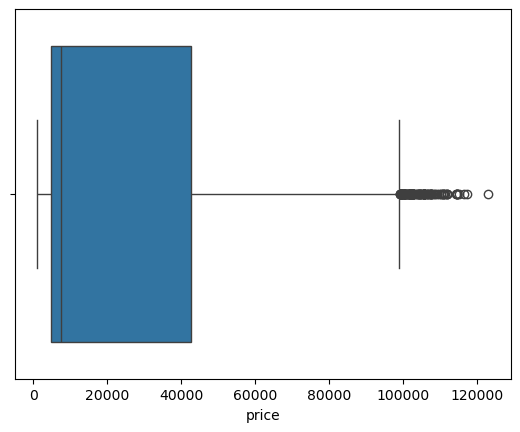

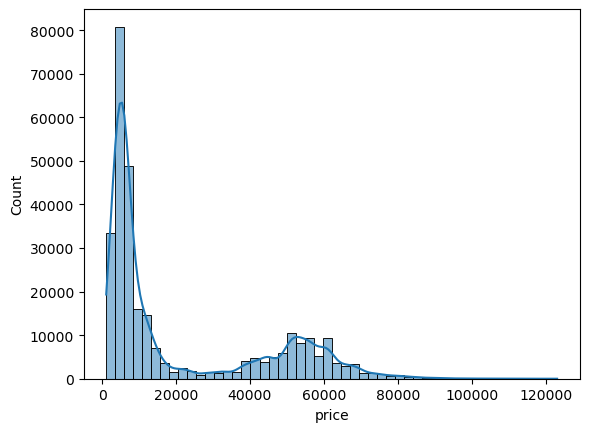

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('C:/Users/Admin/Downloads/Clean_Dataset.csv/Clean_Dataset.csv')
df = df.drop(columns=['Unnamed: 0'])
sns.boxplot(x='price', data=df)
plt.show()
print('')
sns.histplot(df['price'], bins=50, kde=True)
plt.show()

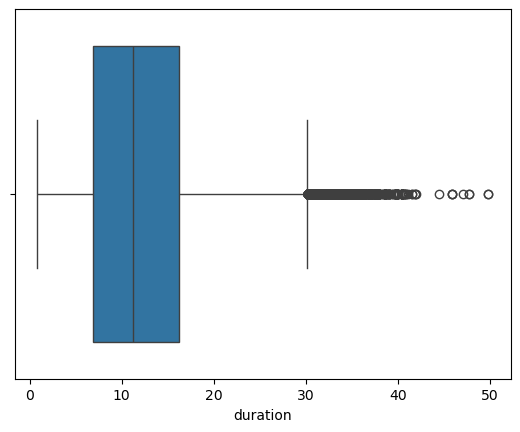

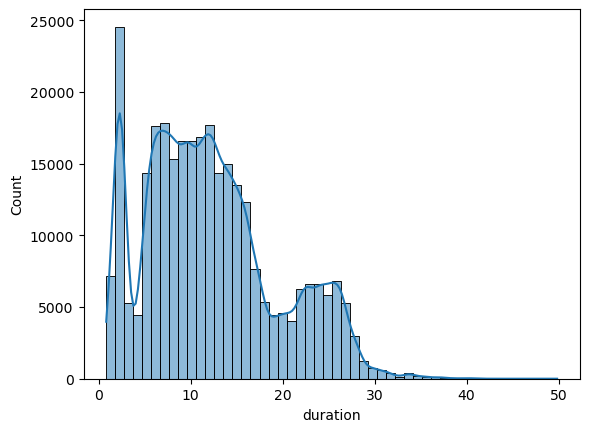

In [30]:
sns.boxplot(x='duration', data=df)
plt.show()
print('')
sns.histplot(df['duration'], bins=50, kde=True)
plt.show()

```
Outliers in Numerical Features.

In [31]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

duration: 2110 outliers
days_left: 0 outliers
price: 123 outliers


duration (2110 outliers): Although this feature has a large number of extreme values, these could represent real scenarios like unusually long flights with layovers or multi-leg journeys. Removing them could cause the model to ignore important real-world cases.

days_left (0 outliers): No extreme values — clean and reliable.

price (123 outliers): Some tickets have very high or very low prices. These may reflect genuine situations such as last-minute bookings or premium flights. Keeping them ensures the model learns the full range of pricing patterns.

<Axes: xlabel='duration', ylabel='price'>

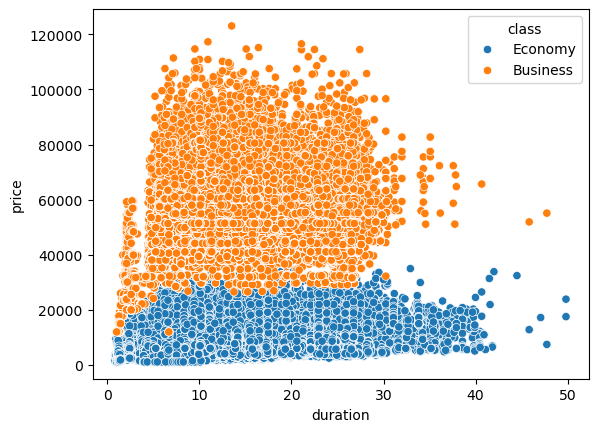

In [36]:
sns.scatterplot(x=df['duration'], y=df['price'], hue=df['class'])

<Axes: xlabel='duration', ylabel='price'>

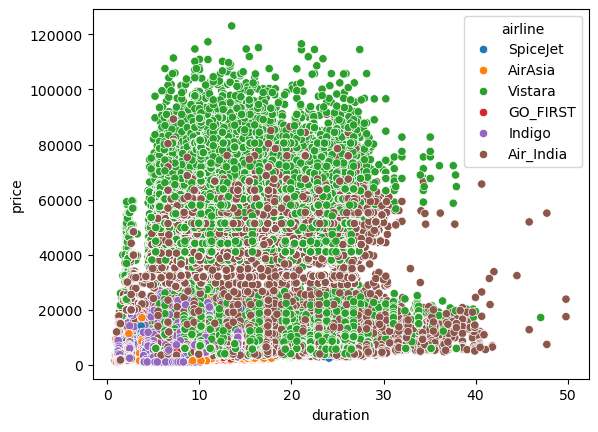

In [40]:
sns.scatterplot(x=df['duration'], y=df['price'], hue=df['airline'])

While flight duration influences ticket prices to some extent, the scatterplot reveals that airline choice and travel class create significant price variation for similar trip lengths. This suggests that pricing is driven more by airline strategy and seat class than by travel time alone.